# Hipótese 4: O detrator crônico

Testa se existe um **traço individual de propensão à detração**, ou seja, se o Cliente que
detratou uma vez tende a detratar de novo mesmo quando o voo seguinte não apresenta falha
operacional.

A hipótese é avaliada por três testes encadeados, que vão retirando progressivamente as
explicações operacionais alternativas:

1. **Concentração**: a repetição da detração ocorre mais do que o acaso explicaria?
2. **Predição**: o histórico separa grupos com risco diferente?
3. **Resistência ao controle**: a diferença sobrevive quando isolamos voos sem falha?

Ao final, um modelo de regressão logística estima o efeito do histórico já descontadas as
condições operacionais do voo.

Variável alvo: `DETRATOR`, definida como `NPS_PRINCIPAL == -100`.

**Base de entrada.** O notebook consome exclusivamente `data/processed/base_analitica.parquet`,
a base analítica oficial já integrada e tratada por `notebooks/pre-processamento.ipynb`. Ele não
lê, concatena, integra ou deduplica os arquivos brutos de `data/raw`: essa etapa pertence só ao
pré-processamento, e repeti-la aqui arriscaria divergir da base analítica definida na seção A.1.3.
A pasta `data/` não é versionada, por compromisso entre o Inteli e o parceiro, então o Parquet
precisa existir localmente (gerado por `notebooks/pre-processamento.ipynb`) antes da execução.
Cada seção numerada abaixo corresponde a um ponto citado na seção 4.2.3 do documento, para que
qualquer número publicado possa ser rastreado até a célula que o produziu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

pd.set_option('display.width', 150)

## 1. Carregar e unir as bases

In [2]:
from pathlib import Path

# A base pode estar sendo executada da raiz do projeto, de dentro de notebooks/ ou no
# Colab: procura data/processed/base_analitica.parquet no diretorio atual, em cada
# diretorio-pai e nos caminhos usuais do Colab. Mesma estrategia de
# notebooks/analise_hipotese_3.ipynb, para as duas analises resolverem o caminho do
# mesmo jeito.
candidatas_raiz = [Path.cwd(), *Path.cwd().parents, Path('/content'), Path('/content/projeto')]
caminho_base = next(
    (raiz / 'data' / 'processed' / 'base_analitica.parquet'
     for raiz in candidatas_raiz
     if (raiz / 'data' / 'processed' / 'base_analitica.parquet').exists()),
    None,
)

if caminho_base is None:
    raise FileNotFoundError(
        'Não encontrei data/processed/base_analitica.parquet. '
        'Execute notebooks/pre-processamento.ipynb antes desta análise.'
    )

df = pd.read_parquet(caminho_base)

# Esta analise nao le, concatena, integra ou deduplica data/raw: essa logica pertence so
# ao pre-processamento oficial. As checagens abaixo so confirmam que a base carregada e a
# base analitica esperada, sem repetir a integracao que a produziu.
colunas_necessarias = {
    'RESPONDENT_ID', 'ID_GOLDENRECORD', 'DATA_STD_CONVERTIDA', 'NPS_PRINCIPAL',
    'ATRASO_CHEGADA', 'ESTATISTICA_ATRASOSAIDA', 'CANCELAMENTO_VOO',
}
faltantes = colunas_necessarias - set(df.columns)
assert not faltantes, f'A base analítica não contém as colunas necessárias: {faltantes}'
assert len(df) == 484_915, (
    f'A base analítica deveria ter 484.915 registros e tem {len(df):,}.'
)
assert df['RESPONDENT_ID'].is_unique, 'RESPONDENT_ID deve estar deduplicado na base analítica.'

# CANCELAMENTO_VOO ja vem como booleano na base tratada; a normalizacao abaixo e uma
# checagem defensiva contra um export que troque o tipo por texto, o que esvaziaria em
# silencio os cortes B e C da secao 5 sem que ninguem percebesse.
if df['CANCELAMENTO_VOO'].dtype == bool:
    df['CANCELADO'] = df['CANCELAMENTO_VOO']
else:
    mapa = {'true': True, 'false': False, 'sim': True, 'nao': False, 'não': False}
    df['CANCELADO'] = df['CANCELAMENTO_VOO'].astype(str).str.strip().str.lower().map(mapa)
assert df['CANCELADO'].notna().all(), 'CANCELAMENTO_VOO tem valor fora do esperado'

df['DETRATOR'] = (df['NPS_PRINCIPAL'] == -100).astype(int)

print(f'Base analítica carregada: {len(df):,} registros de {caminho_base}')
print(f'Clientes distintos: {df["ID_GOLDENRECORD"].nunique():,}')
print(f'Taxa geral de detratores: {df["DETRATOR"].mean() * 100:.1f}%')


Base analítica carregada: 484,915 registros de c:\Users\fejst\Downloads\g01\data\processed\base_analitica.parquet
Clientes distintos: 407,139
Taxa geral de detratores: 20.4%


## 2. Construir o histórico de detração

Para cada Cliente, as respostas são ordenadas **por data** e cada linha recebe o resultado da
**resposta anterior daquele mesmo Cliente**. Só entram na análise as respostas que têm uma anterior.

Este é o ponto que garante ausência de vazamento de informação: a resposta anterior já existia
antes do voo novo acontecer, então usá-la como preditor é legítimo. A ordenação é feita por
`DATA_STD_CONVERTIDA`, já produzida pelo pré-processamento, e não pela ordem do arquivo nem pelo
`RESPONDENT_ID`, que acompanha a cronologia na maior parte dos casos mas não em todos. Quando duas
respostas do mesmo Cliente caem no mesmo dia, o `RESPONDENT_ID` desempata de forma determinística,
e a célula abaixo informa quantos pares estão nessa situação. Só são removidos os registros sem
`ID_GOLDENRECORD`; um registro sem data continua na análise e é ordenado ao final do histórico do
seu Cliente.

In [3]:
d = df.dropna(subset=['ID_GOLDENRECORD']).sort_values(
    ['ID_GOLDENRECORD', 'DATA_STD_CONVERTIDA', 'RESPONDENT_ID']
).copy()
g = d.groupby('ID_GOLDENRECORD')

d['DET_ANTERIOR']     = g['DETRATOR'].shift(1)
d['ATRASO_ANTERIOR']  = g['ATRASO_CHEGADA'].shift(1)
d['DATA_ANTERIOR']    = g['DATA_STD_CONVERTIDA'].shift(1)

hist = d.dropna(subset=['DET_ANTERIOR']).copy()

print(f'Respostas com histórico: {len(hist)}')
print(f'Cobertura sobre a base: {len(hist)/len(df)*100:.1f}%')
print(f'Pares no mesmo dia, desempatados por RESPONDENT_ID: {int((hist["DATA_STD_CONVERTIDA"] == hist["DATA_ANTERIOR"]).sum())}')

Respostas com histórico: 77673
Cobertura sobre a base: 16.0%
Pares no mesmo dia, desempatados por RESPONDENT_ID: 375


## 3. Teste 1: concentração

Entre os Clientes com **exatamente duas respostas**, se detratar fosse independente a cada
viagem, a combinação "detratou nas duas" deveria aparecer com a frequência esperada pelo
produto das marginais. O qui-quadrado mede o afastamento entre observado e esperado.

O valor publicado é o **sem correção de continuidade de Yates**. A célula imprime também o valor
com a correção, para deixar registrado que a escolha da convenção não muda a conclusão.

In [4]:
contagem = d.groupby('ID_GOLDENRECORD')['DETRATOR'].size()
dois = d[d['ID_GOLDENRECORD'].isin(contagem[contagem == 2].index)]

par = dois.groupby('ID_GOLDENRECORD')['DETRATOR'].agg(['first', 'last'])
tabela = pd.crosstab(par['first'], par['last'])
tabela.index.name, tabela.columns.name = 'primeira resposta', 'segunda resposta'

chi2, p, gl, esperado = stats.chi2_contingency(tabela, correction=False)
chi2_yates, _, _, _ = stats.chi2_contingency(tabela, correction=True)

print(tabela, '\n')
print(f'Clientes com exatamente duas respostas: {int(tabela.values.sum())}')
print(f'"detratou nas duas": observado = {tabela.loc[1, 1]}  |  esperado = {esperado[1][1]:.0f}')
print(f'qui-quadrado = {chi2:.1f}   gl = {gl}   p = {p:.3e}')
print(f'qui-quadrado com correcao de Yates = {chi2_yates:.1f}')

segunda resposta       0     1
primeira resposta             
0                  25117  4292
1                   4404  3288 

Clientes com exatamente duas respostas: 37101
"detratou nas duas": observado = 3288  |  esperado = 1572
qui-quadrado = 2972.4   gl = 1   p = 0.000e+00
qui-quadrado com correcao de Yates = 2970.7


## 4. Teste 2: predição

Entre as respostas que têm histórico, compara-se a taxa de detração de quem detratou antes
contra a de quem não detratou.

In [5]:
taxa = hist.groupby('DET_ANTERIOR')['DETRATOR'].agg(['size', 'mean'])
taxa['mean'] = taxa['mean'] * 100
taxa.index = ['nao detratou antes', 'detratou antes']
taxa.columns = ['n', 'taxa de detracao (%)']

print(taxa.round(1))
print(f'\nRazao entre os grupos: {taxa.iloc[1, 1] / taxa.iloc[0, 1]:.1f}x')

                        n  taxa de detracao (%)
nao detratou antes  61902                  14.3
detratou antes      15771                  42.9

Razao entre os grupos: 3.0x


## 5. Teste 3: resistência ao controle

Aqui está o teste decisivo. Se a repetição fosse apenas consequência de o Cliente ter pegado
voos piores, a diferença deveria **encolher** quando isolamos apenas voos sem falha. Os cortes
são progressivamente mais restritivos:

- **Corte A**: todas as respostas com histórico
- **Corte B**: voo atual sem atraso na saída, sem atraso na chegada e sem cancelamento
- **Corte C**: o corte B, exigindo também que o voo anterior tenha chegado sem atraso

In [6]:
voo_perfeito = (
    (hist['ATRASO_CHEGADA'] == 0)
    & (hist['ESTATISTICA_ATRASOSAIDA'] == 0)
    & (~hist['CANCELADO'])
)

cortes = {
    'A. todas as respostas com historico': hist,
    'B. voo atual sem falha':              hist[voo_perfeito],
    'C. B + voo anterior sem atraso':      hist[voo_perfeito & (hist['ATRASO_ANTERIOR'] == 0)],
}

linhas = []
for nome, sub in cortes.items():
    r = sub.groupby('DET_ANTERIOR')['DETRATOR'].mean() * 100
    linhas.append({'corte': nome, 'n': len(sub),
                   'sem historico (%)': round(r[0.0], 1),
                   'com historico (%)': round(r[1.0], 1),
                   'razao': round(r[1.0] / r[0.0], 1)})

resultado = pd.DataFrame(linhas).set_index('corte')
print(resultado)

                                         n  ...  razao
corte                                       ...       
A. todas as respostas com historico  77673  ...    3.0
B. voo atual sem falha               39029  ...    3.9
C. B + voo anterior sem atraso       31469  ...    4.2

[3 rows x 4 columns]


## 6. Visualização

O gráfico mostra o que sustenta a hipótese: conforme as causas operacionais são removidas, a
distância entre os dois grupos **aumenta** em vez de diminuir.

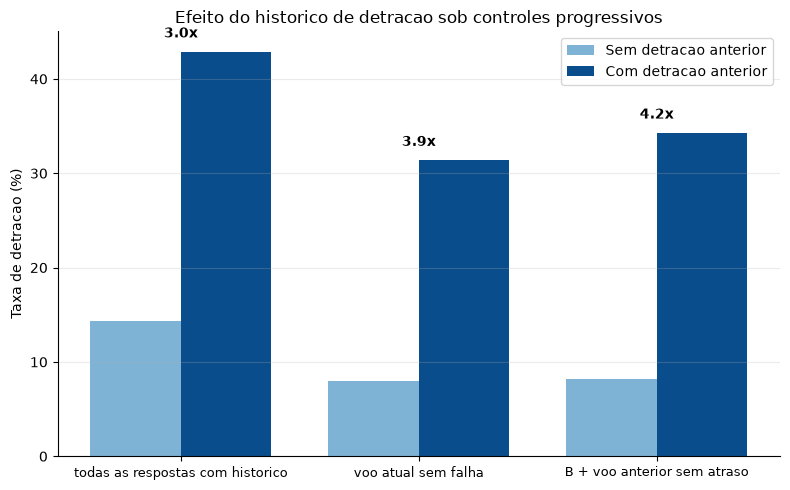

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(resultado))
largura = 0.38

ax.bar(x - largura/2, resultado['sem historico (%)'], largura,
       label='Sem detracao anterior', color='#7fb3d5')
ax.bar(x + largura/2, resultado['com historico (%)'], largura,
       label='Com detracao anterior', color='#0a4d8c')

for i, (_, r) in enumerate(resultado.iterrows()):
    ax.text(i, r['com historico (%)'] + 1.5, f"{r['razao']}x",
            ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([c.split('. ')[1] for c in resultado.index], fontsize=9)
ax.set_ylabel('Taxa de detracao (%)')
ax.set_title('Efeito do historico de detracao sob controles progressivos')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=.25)
fig.tight_layout()
plt.show()

## 7. Modelo ajustado

A regressão logística estima o efeito do histórico com as condições operacionais do voo
incluídas como controle, de modo que o resultado não possa ser atribuído a elas.

In [8]:
# CANCELADO ja e o indicador booleano normalizado na secao 1. Usa-lo direto evita o
# get_dummies, que devolveria a coluna intacta, sem virar indicador, se o tipo mudasse.
X = pd.DataFrame({
    'CANCELADO':      hist['CANCELADO'].astype(float).values,
    'ATRASO_CHEGADA': hist['ATRASO_CHEGADA'].astype(float).values,
    'DET_ANTERIOR':   hist['DET_ANTERIOR'].astype(float).values,
})
X = sm.add_constant(X)

modelo = sm.Logit(hist['DETRATOR'].astype(float).values, X).fit(disp=0)

odds = np.exp(modelo.params['DET_ANTERIOR'])
ic   = np.exp(modelo.conf_int().loc['DET_ANTERIOR'])

print(f'n = {len(hist)}')
print(f'odds ratio do historico de detracao = {odds:.2f}')
print(f'IC 95% = [{ic[0]:.2f}, {ic[1]:.2f}]')
print(f'p = {modelo.pvalues["DET_ANTERIOR"]:.3e}')

n = 77673
odds ratio do historico de detracao = 4.61
IC 95% = [4.43, 4.79]
p = 0.000e+00


## Conclusão

- **Concentração**: a combinação "detratou nas duas" aparece muito acima do esperado sob
  independência, com qui-quadrado alto e p < 0,001. A repetição não é acaso.
- **Predição**: o histórico separa a base em dois grupos com risco cerca de três vezes
  diferente.
- **Resistência ao controle**: a razão entre os grupos **aumenta** conforme as causas
  operacionais são removidas. É o oposto do que se esperaria se o efeito fosse do voo, e é o
  resultado que sustenta a hipótese.
- **Modelo ajustado**: o histórico permanece fortemente associado à detração mesmo controlando
  por atraso na chegada e cancelamento.

**Para o modelo preditivo.** O histórico de detração é um preditor forte e legítimo, já que a
resposta anterior existe antes do voo novo e portanto não gera vazamento. É também um alerta de
viés, porque parte do que hoje se atribui ao atraso pode ser o mesmo Cliente insatisfeito
aparecendo repetidas vezes.

**Ressalvas.** O histórico existe para apenas cerca de 16% da base, o que torna a variável um
preditor complementar e nunca principal. Além disso, os dados não permitem separar insatisfação
crônica de estilo de resposta, ou seja, a tendência de certas pessoas a usarem sempre o extremo
baixo da escala. Por isso o padrão é tratado aqui como indício consistente de um traço de
detrator crônico, e não como confirmação definitiva de sua existência.